# Art as Data

[Project extensions are at the bottom of this file]

Piet Mondrian was a Dutch artist best known for his abstract, grid-like designs during the 1920s and 30s. Mondrian was part of an art movement that aimed to explore and express simplicity by using only the most basic colors and shapes.

How might we represent the features of a Mondrian painting using tabular data? Here is one approach:

| painting_id | feature | x   | y   | width | height | color  | rgb      |
|------------|---------|-----|-----|-------|--------|--------|----------|
| b219       | rect    | 0   | 0   | 121   | 152    | white  | #ffffff  |
| b219       | rect    | 132 | 0   | 378   | 365    | red    | #e6151a  |
| b219       | rect    | 0   | 173 | 121   | 192    | white  | #ffffff  |
| b219       | rect    | 0   | 377 | 121   | 133    | blue   | #2f5a9f  |
| b219       | rect    | 132 | 377 | 335   | 133    | white  | #ffffff  |
| b219       | rect    | 479 | 377 | 31    | 59     | white  | #ffffff  |
| b219       | rect    | 479 | 451 | 31    | 59     | yellow | #f7ed2d  |
| b219       | h-line  | 0   | 365 | 510   | 12     | black  | #000000  |
| b219       | v-line  | 121 | 0   | 11    | 510    | black  | #000000  |
| b219       | v-line  | 467 | 377 | 12    | 133    | black  | #000000  |
| b219       | h-line  | 0   | 152 | 121   | 21     | black  | #000000  |
| b219       | h-line  | 479 | 436 | 31    | 15     | black  | #000000  |

This table represents the features of the painting using 12 rows of data. Notice how each row represents a rectangular shape with x-y coordinates, size and color info.

By representing art as data, we open up artistic analysis to a broad range of data science techniques. In this project, we will explore Mondrian's quest for artistic simplicity and try our hands at detecting fake paintings falsely attributed to Mondrian.

### Loading the Data
The `mondrian-painting-features.csv` file contains digitized features for 136 Mondrian paintings over the 2 decades from 1920 to 1940. Load the data into python and take a look.

Activity Goals:
- Import pandas.
- Load the features data.
- Display the dataframe.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'mondrian-painting-features.csv', 'mondrian-painting-info.csv', and 'fp26-features.csv'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
pd.options.display.max_rows = 10 

features = pd.read_csv('mondrian-painting-features.csv')
features 

,painting_id,feature,x,y,width,height,color,rgb
0,b104,rect,0,0,146,13,white,#ced2ca
1,b104,rect,151,0,576,13,gray,#a4a7a7
2,b104,rect,732,0,278,129,gray,#c8c9c7
3,b104,rect,0,18,146,468,white,#cfd0ce
4,b104,rect,151,18,107,111,black,#151d16
...,...,...,...,...,...,...,...,...
3199,b296,v-line,620,0,19,825,black,#000000
3200,b296,v-line,49,508,19,79,black,#000000
3201,b296,h-line,0,268,711,19,black,#000000
3202,b296,h-line,0,489,711,19,black,#000000


The first painting in this dataset has an ID of b104. We can see that there are multiple rows with that same painting ID.

Let's use a `query` to extract all the features associated with that first painting.

Activity Goal:
- Find all the features for painting b104.

In [3]:
features.query('painting_id == "b104"')

,painting_id,feature,x,y,width,height,color,rgb
0,b104,rect,0,0,146,13,white,#ced2ca
1,b104,rect,151,0,576,13,gray,#a4a7a7
2,b104,rect,732,0,278,129,gray,#c8c9c7
3,b104,rect,0,18,146,468,white,#cfd0ce
4,b104,rect,151,18,107,111,black,#151d16
...,...,...,...,...,...,...,...,...
36,b104,v-line,727,0,5,1007,black,#000000
37,b104,v-line,258,18,5,111,black,#000000
38,b104,v-line,531,134,5,809,black,#000000
39,b104,v-line,944,134,5,873,black,#000000


From this we see that painting b104 has 41 features.

We have got the features for this painting, but what if we are interested in the year it was painted?

For that, we need to load up a separate data file: `mondrian-painting-info.csv`.

Activity Goals:
- Load the painting info data.
- Display the dataframe.

In [4]:
painting_info = pd.read_csv('mondrian-painting-info.csv')
painting_info

,painting_id,year,title,width,height
0,b104,1920,No. VI,1010,1007
1,b105,1920,Composition A,918,900
2,b106,1920,Composition B,575,677
3,b107,1920,Composition C,610,603
4,b108,1920,Composition I,646,750
...,...,...,...,...,...
131,b292,1939,Composition no. 1,1023,1052
132,b293,1939,"Composition of red, blue and white: II",330,435
133,b294,1939,Trafalgar Square,1200,1452
134,b295,1939,Composition no. 8,681,752


Each row represents one painting. Now we see that b104 was painted in the year 1920. Later, when we calculate painting metrics, we'll merge additional columns onto this `painting_info` dataframe.

### Turning Data into Pictures
For this project, we've provided the following function to draw Mondrian paintings from data:


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
def draw_mondrian( painting_id ):
    rects = features.query('painting_id == @painting_id')
    total_width = rects.eval("x + width").max()
    total_height = rects.eval("y + height").max()
    
    fig, ax = plt.subplots(figsize=(3, 3))
    
    for (idx, row) in rects.iterrows():
        x, y, w, h, rgb = row[['x','y','width','height','rgb']]
        patch = mpatches.Rectangle((x, y), w, h, facecolor=rgb)
        ax.add_patch(patch)
    
    ax.axis([0, total_width, 0, total_height])
    ax.set_aspect('equal')
    ax.axis('off')
    fig.text(0.5, 0.01, painting_id, ha="center", fontsize=14)


Internally, this function uses Matplotlib to draw each feature as a rectangular patch of color. While the details of this function are not the focus of this project, feel free to take a look at the code to see how it works.

We can run this function any time we want to visualize a painting. For example, let's see what the first painting in our dataset (b104) looks like.

Activity Goal:
- Draw painting bl014.

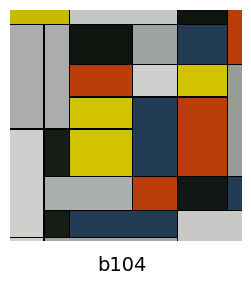

In [6]:
draw_mondrian('b104')

We went from art to data and back again. Cool!

### Comparing Complexity

As mentioned earlier, Piet Mondrian was part of a movement to simplify artistic expression. Do Mondrian paintings vary substantially in their simplicity?

Let's use our `draw_mondrian()` function to draw two separate paintings and see if we notice any differences in complexity.

Activity Goal:
- Draw two separate Mondrain paintings.


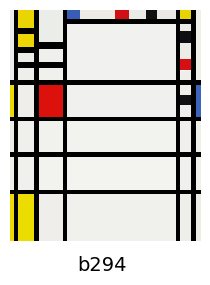

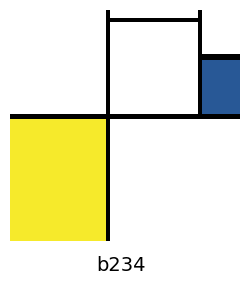

In [7]:
draw_mondrian('b294')
draw_mondrian('b234')

The left painting is more complex due to having more horizontal lines, vertical lines, and rectangles.

### Quantifying Complexity
Art researchers have used a variety of approaches to quantify the complexity of Mondrian paintings. Perhaps the easiest method is to simply count the number of features in a given painting. Let's explore this basic metric and see if we encounter any interesting trends over time.

As a reminder, here is the `features` dataframe.

In [8]:
pd.options.display.max_rows = 6
features

,painting_id,feature,x,y,width,height,color,rgb
0,b104,rect,0,0,146,13,white,#ced2ca
1,b104,rect,151,0,576,13,gray,#a4a7a7
2,b104,rect,732,0,278,129,gray,#c8c9c7
...,...,...,...,...,...,...,...,...
3201,b296,h-line,0,268,711,19,black,#000000
3202,b296,h-line,0,489,711,19,black,#000000
3203,b296,h-line,0,679,11,28,black,#000000


To count the number of features for each painting, let's use `df.groupby()`.

Activity Goals:
- Group the features by painting_id.
- Count the number of rows in each group.
- Display the counts.

In [9]:
pd.options.display.max_rows = 10
sizes = features.groupby('painting_id').size()
sizes #display the result


painting_id
b104    41
b105    42
b106    41
b107    44
b108    44
        ..
b292    31
b293    26
b294    62
b295    47
b296    49
Length: 136, dtype: int64

This gives us the number of features for all 136 paintings. The output above is a 1-dimensional series where the index is the `painting_id`.

Let's turn the series into a dataframe by calling `reset_index( )`.

In [10]:
complexity_df = sizes.reset_index(name='complexity')
complexity_df

,painting_id,complexity
0,b104,41
1,b105,42
2,b106,41
3,b107,44
4,b108,44
...,...,...
131,b292,31
132,b293,26
133,b294,62
134,b295,47


This gives us a dataframe with the complexity (number of features) for each painting ID. null We now have complexity data for all 136 paintings.

### Merging Data
We want to plot complexity over time, but currently we have complexity in one dataframe and the year in a different dataframe.

In [11]:
pd.options.display.max_rows = 6
complexity_df

,painting_id,complexity
0,b104,41
1,b105,42
2,b106,41
...,...,...
133,b294,62
134,b295,47
135,b296,49


In [12]:
painting_info


,painting_id,year,title,width,height
0,b104,1920,No. VI,1010,1007
1,b105,1920,Composition A,918,900
2,b106,1920,Composition B,575,677
...,...,...,...,...,...
133,b294,1939,Trafalgar Square,1200,1452
134,b295,1939,Composition no. 8,681,752
135,b296,1940,Composition no. 11,711,825


Let's add the complexity data into the `painting_info` dataframe using a left merge. This will allow us to plot how complexity changes by year.

Merging dataframes in Pandas is like joining tables in SQL. We need to specify which columns will be used to find matching rows. In our case, each row for both dataframes represents a single painting. Rows can be matched using the `painting_id` column.

Activity Goals:
- Merge `complexity_df` into `painting_info`.
- Display the result.

In [13]:
pd.options.display.max_rows = 10
painting_info = painting_info.merge(complexity_df, on='painting_id', how='left')
painting_info

,painting_id,year,title,width,height,complexity
0,b104,1920,No. VI,1010,1007,41
1,b105,1920,Composition A,918,900,42
2,b106,1920,Composition B,575,677,41
3,b107,1920,Composition C,610,603,44
4,b108,1920,Composition I,646,750,44
...,...,...,...,...,...,...
131,b292,1939,Composition no. 1,1023,1052,31
132,b293,1939,"Composition of red, blue and white: II",330,435,26
133,b294,1939,Trafalgar Square,1200,1452,62
134,b295,1939,Composition no. 8,681,752,47


We have now merged the `complexity_df` into `painting_info`.

### Plotting Complexity over Time
Are you ready to make some graphs?

Let's visualize how complexity changes over the years for these Mondrian paintings. A scatterplot would work well for this.

Activity Goals:
- Import matplotlib.pyplot.
- Create a scatterplot of complexity over time.
- Label the axes.

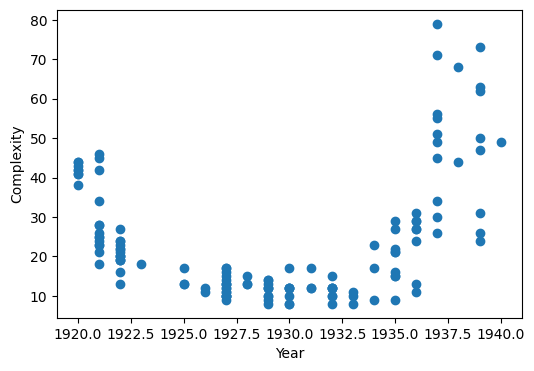

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.scatter(painting_info['year'], painting_info['complexity'])
plt.xlabel('Year')
plt.ylabel('Complexity')
plt.show()

The complexity of Mondrian's paintings increases after 1935, indicating a shift in his artistic style.

### Detecting Possible Fake Paintings
Since Mondrian paintings can sell for millions of dollars, it's not hard to imagine that someone might try to create a forgery. The following is a widely shared painting claimed to be a Mondrian artwork from 1926.

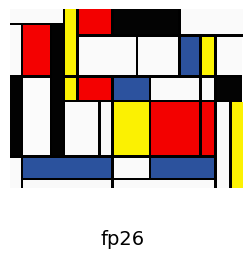

In [15]:
# code to plot the figure
rects = pd.read_csv('fp26-features.csv')
total_width = rects.eval("x + width").max()
total_height = rects.eval("y + height").max()

fig, ax = plt.subplots(figsize=(3, 3))

for (idx, row) in rects.iterrows():
	x, y, w, h, rgb = row[['x','y','width','height','rgb']]
	patch = mpatches.Rectangle((x, y), w, h, facecolor=rgb)
	ax.add_patch(patch)

ax.axis([0, total_width, 0, total_height])
ax.set_aspect('equal')
ax.axis('off')
fig.text(0.5, 0.01, 'fp26', ha="center", fontsize=14)
plt.show()


This painting doesn't show up in our catalog. Is it real or fake? Let's see what evidence we can glean from the data.

Load up the feature data for this painting from the file `fp26-features.csv`.

Activity Goals:
- Load the features for fake painting 1926.
- Display the Dataframe.

In [16]:
fp26_features = pd.read_csv('fp26-features.csv')
fp26_features 

,painting_id,feature,x,y,width,height,color,rgb
0,fp26,rect,0,0,34,92,white,#fafafa
1,fp26,rect,41,0,267,22,white,#f9f9f9
2,fp26,rect,317,0,309,22,white,#fafafa
3,fp26,rect,634,0,38,261,white,#fafafa
4,fp26,rect,680,0,32,261,yellow,#fcf202
...,...,...,...,...,...,...,...,...
49,fp26,h-line,206,462,506,8,black,#000000
50,fp26,h-line,0,497,166,8,black,#000000
51,fp26,v-line,270,96,9,169,black,#000000
52,fp26,v-line,580,96,7,370,black,#000000


Using our number of features metric for complexity, we can see that this painting has a complexity of 54.

Is a complexity of 54 consistent with other Mondrain paintings in the year 1926? Let's add this datapoint to our scatterplot for a visual comparison.

Activity Goals:
- Recreate the scatterplot from earlier.
- Plot the new point as a red square.
- Label the axes.

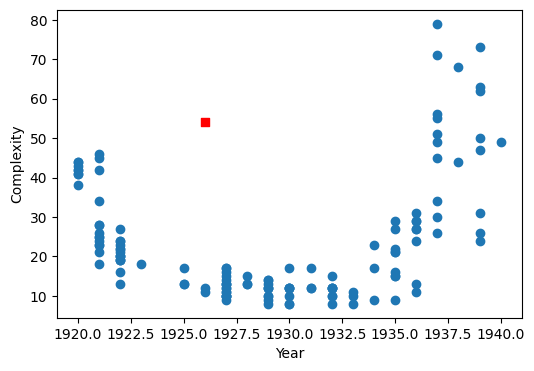

In [17]:
plt.figure(figsize=(6, 4))
plt.scatter(painting_info['year'], painting_info['complexity'])
plt.scatter(x=1926, y=54, color='red', marker='s')
plt.xlabel('Year')
plt.ylabel('Complexity')
plt.show()


The 1926 painting is an outlier with much higher complexity than other paintings from that period, suggesting it might be a fake.


## Project extensions

Here are some ideas for extending the project:

1. **Analyze painting dimensions over time**  
    
    Plot the length, width, or area of each painting against its creation date. Are there any noticeable trends or patterns?

2. **Track blue color usage over time**  
   - Compute the total area of each painting using data from `painting_info`.  

   - Identify features in the dataset where the color is 'blue'. 

   - Calculate the area of these blue features.  

   - Group the blue feature areas by `painting_id` and sum them. 

   - Merge this data with `painting_info`.  

   - Plot the percentage of blue in each painting over time.

   - Repeat with other colors (red, yellow, white, black, gray)

---
## Extensión 1: Analizar las dimensiones de las pinturas a lo largo del tiempo

En esta extensión, graficamos el ancho, la altura y el área de cada pintura contra su fecha de creación para buscar tendencias o patrones notables.

**Objetivos de la actividad:**
- Calcular el área de cada pintura (ancho × altura).
- Crear gráficos de dispersión del ancho, la altura y el área a lo largo del tiempo.
- Identificar tendencias o patrones.

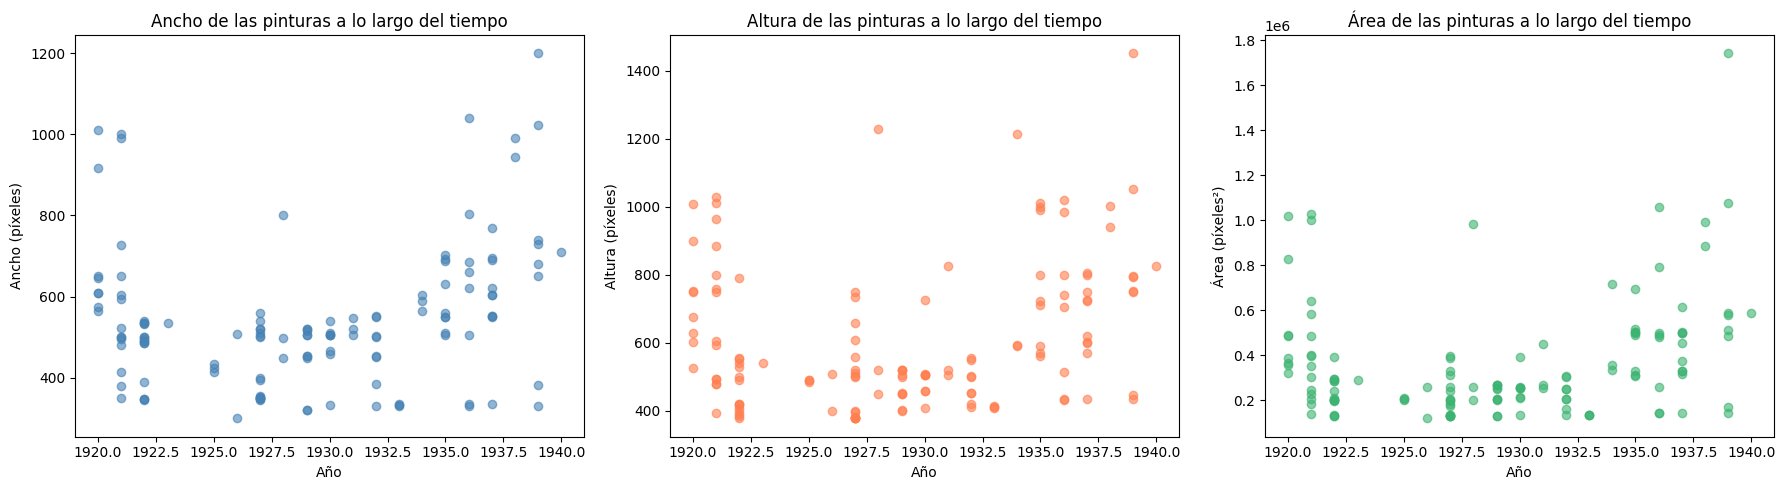

In [18]:
# Extensión 1: Analizar las dimensiones de las pinturas a lo largo del tiempo

# Calcular el área de cada pintura
painting_info['area'] = painting_info['width'] * painting_info['height']

# Crear una figura con 3 subgráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Ancho a lo largo del tiempo
axes[0].scatter(painting_info['year'], painting_info['width'], alpha=0.6, color='steelblue')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Ancho (píxeles)')
axes[0].set_title('Ancho de las pinturas a lo largo del tiempo')

# Gráfico 2: Altura a lo largo del tiempo
axes[1].scatter(painting_info['year'], painting_info['height'], alpha=0.6, color='coral')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Altura (píxeles)')
axes[1].set_title('Altura de las pinturas a lo largo del tiempo')

# Gráfico 3: Área a lo largo del tiempo
axes[2].scatter(painting_info['year'], painting_info['area'], alpha=0.6, color='mediumseagreen')
axes[2].set_xlabel('Año')
axes[2].set_ylabel('Área (píxeles²)')
axes[2].set_title('Área de las pinturas a lo largo del tiempo')

plt.tight_layout()
plt.show()

### Observaciones de la Extensión 1

Al analizar los gráficos podemos observar cómo evolucionaron las dimensiones de las pinturas de Mondrian a lo largo de las dos décadas (1920-1940). Cualquier tendencia visible (por ejemplo, pinturas más grandes o más pequeñas con el tiempo) nos da información sobre cómo cambió su enfoque artístico.

---
## Extensión 2: Rastrear el uso del color azul a lo largo del tiempo

En esta extensión, calculamos qué porcentaje de cada pintura es de color azul y graficamos este porcentaje a lo largo del tiempo. Luego repetimos el análisis con los demás colores (rojo, amarillo, blanco, negro, gris).

**Objetivos de la actividad:**
- Calcular el área total de cada pintura usando los datos de `painting_info`.
- Identificar las características (features) donde el color es 'blue'.
- Calcular el área de esas características azules.
- Agrupar las áreas azules por `painting_id` y sumarlas.
- Fusionar estos datos con `painting_info`.
- Graficar el porcentaje de azul en cada pintura a lo largo del tiempo.
- Repetir con otros colores (rojo, amarillo, blanco, negro, gris).

In [19]:
# Extensión 2 - Paso 1: Calcular el área total de cada pintura
# (ya calculamos 'area' en la extensión anterior)

# Verificar que painting_info ya tiene la columna 'area'
if 'area' not in painting_info.columns:
    painting_info['area'] = painting_info['width'] * painting_info['height']

print('Área total de cada pintura:')
painting_info[['painting_id', 'year', 'area']].head(10)

Área total de cada pintura:


,painting_id,year,area
0,b104,1920,1017070
1,b105,1920,826200
2,b106,1920,389275
3,b107,1920,367830
4,b108,1920,484500
5,b109,1920,355320
6,b113,1920,490203
7,b114,1920,320250
8,b115,1921,400000
9,b116,1921,643395


In [20]:
# Extensión 2 - Paso 2: Función para calcular el porcentaje de un color

def calcular_porcentaje_color(features_df, painting_info_df, color_nombre):
    """
    Calcula el porcentaje de área que ocupa un color específico en cada pintura.
    
    Parámetros:
    - features_df: DataFrame con las características de las pinturas
    - painting_info_df: DataFrame con la información de las pinturas
    - color_nombre: nombre del color a buscar (ej: 'blue', 'red', etc.)
    
    Retorna:
    - DataFrame con painting_id, year y el porcentaje del color
    """
    # Filtrar las características del color especificado
    color_features = features_df.query('color == @color_nombre').copy()
    
    # Calcular el área de cada característica de color
    color_features['feature_area'] = color_features['width'] * color_features['height']
    
    # Agrupar por painting_id y sumar las áreas del color
    color_area_by_painting = color_features.groupby('painting_id')['feature_area'].sum().reset_index()
    color_area_by_painting.columns = ['painting_id', f'{color_nombre}_area']
    
    # Fusionar con painting_info para obtener el año y el área total
    resultado = painting_info_df[['painting_id', 'year', 'area']].merge(
        color_area_by_painting, on='painting_id', how='left'
    )
    
    # Rellenar NaN con 0 (pinturas que no tienen ese color)
    resultado[f'{color_nombre}_area'] = resultado[f'{color_nombre}_area'].fillna(0)
    
    # Calcular el porcentaje
    resultado[f'{color_nombre}_pct'] = (resultado[f'{color_nombre}_area'] / resultado['area']) * 100
    
    return resultado

print('Función calcular_porcentaje_color() definida correctamente.')

Función calcular_porcentaje_color() definida correctamente.


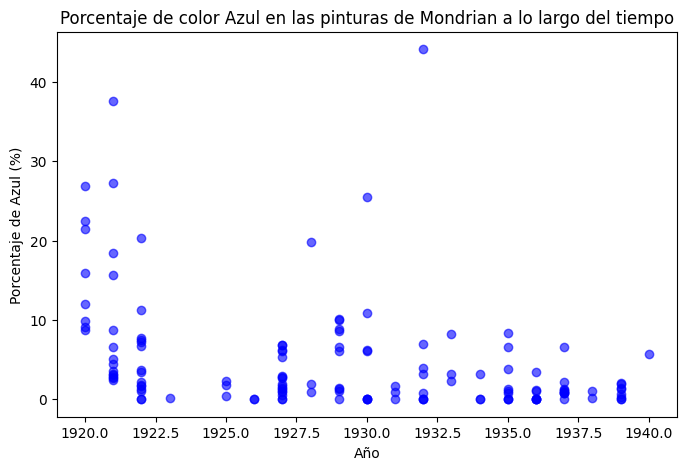

In [21]:
# Extensión 2 - Paso 3: Calcular y graficar el porcentaje de AZUL a lo largo del tiempo

blue_data = calcular_porcentaje_color(features, painting_info, 'blue')

plt.figure(figsize=(8, 5))
plt.scatter(blue_data['year'], blue_data['blue_pct'], alpha=0.6, color='blue')
plt.xlabel('Año')
plt.ylabel('Porcentaje de Azul (%)')
plt.title('Porcentaje de color Azul en las pinturas de Mondrian a lo largo del tiempo')
plt.show()

### Análisis del color Azul

El gráfico nos muestra cómo Mondrian utilizó el color azul a lo largo de los años. Podemos observar si el uso del azul aumentó, disminuyó o se mantuvo constante durante las dos décadas de su carrera cubista.

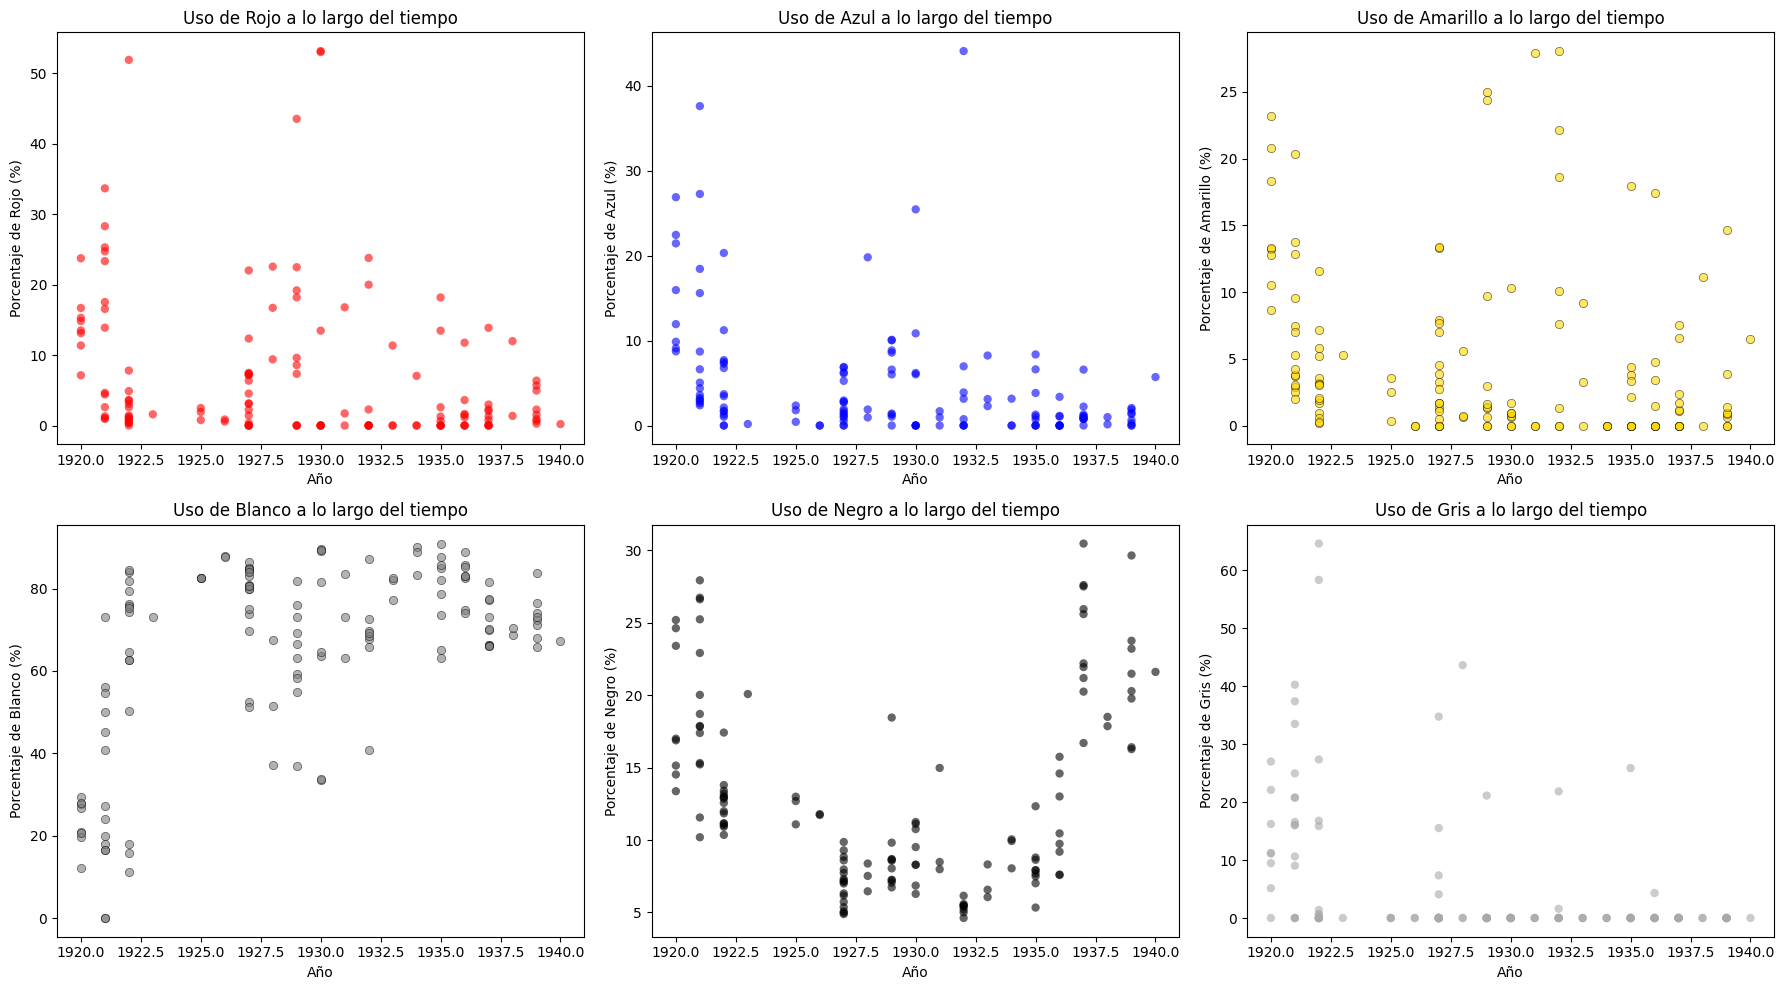

In [22]:
# Extensión 2 - Paso 4: Repetir con TODOS los colores

# Lista de colores a analizar y sus colores correspondientes para graficar
colores = {
    'red': {'plot_color': 'red', 'nombre_es': 'Rojo'},
    'blue': {'plot_color': 'blue', 'nombre_es': 'Azul'},
    'yellow': {'plot_color': 'gold', 'nombre_es': 'Amarillo'},
    'white': {'plot_color': 'gray', 'nombre_es': 'Blanco'},
    'black': {'plot_color': 'black', 'nombre_es': 'Negro'},
    'gray': {'plot_color': 'darkgray', 'nombre_es': 'Gris'}
}

# Crear una figura con 6 subgráficos (2 filas × 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Aplanar para iterar fácilmente

for i, (color_en, info) in enumerate(colores.items()):
    # Calcular el porcentaje del color
    color_data = calcular_porcentaje_color(features, painting_info, color_en)
    
    # Graficar
    axes[i].scatter(
        color_data['year'], 
        color_data[f'{color_en}_pct'], 
        alpha=0.6, 
        color=info['plot_color'],
        edgecolors='black' if color_en in ['white', 'yellow'] else 'none',
        linewidths=0.5
    )
    axes[i].set_xlabel('Año')
    axes[i].set_ylabel(f'Porcentaje de {info["nombre_es"]} (%)')
    axes[i].set_title(f'Uso de {info["nombre_es"]} a lo largo del tiempo')

plt.tight_layout()
plt.show()

### Observaciones de la Extensión 2

Los gráficos anteriores nos muestran cómo Mondrian utilizó cada color a lo largo de su carrera (1920-1940):

- **Rojo**: Podemos observar cómo el uso del rojo varió a lo largo del tiempo.
- **Azul**: El porcentaje de azul en las pinturas muestra tendencias interesantes.
- **Amarillo**: El amarillo es generalmente uno de los colores menos utilizados.
- **Blanco**: El blanco típicamente ocupa la mayor proporción de las pinturas.
- **Negro**: El negro se utiliza principalmente para las líneas que definen la cuadrícula.
- **Gris**: El uso del gris puede variar significativamente entre periodos.

Estos patrones de uso de color nos dan información valiosa sobre la evolución del estilo artístico de Mondrian y su búsqueda de la simplicidad visual.

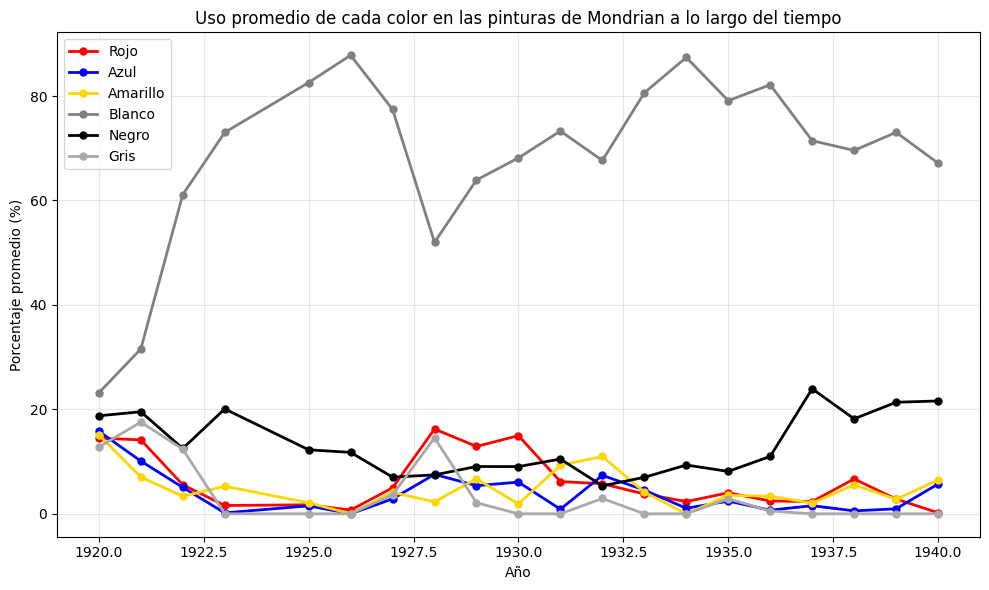

In [23]:
# Extensión 2 - Paso 5 (Bonus): Gráfico combinado de todos los colores

plt.figure(figsize=(10, 6))

for color_en, info in colores.items():
    color_data = calcular_porcentaje_color(features, painting_info, color_en)
    
    # Calcular el promedio por año para cada color
    promedio_por_anio = color_data.groupby('year')[f'{color_en}_pct'].mean()
    
    plt.plot(
        promedio_por_anio.index, 
        promedio_por_anio.values, 
        marker='o', 
        label=info['nombre_es'],
        color=info['plot_color'],
        linewidth=2,
        markersize=5
    )

plt.xlabel('Año')
plt.ylabel('Porcentaje promedio (%)')
plt.title('Uso promedio de cada color en las pinturas de Mondrian a lo largo del tiempo')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusión

El gráfico combinado nos permite comparar directamente cómo evolucionó el uso de cada color a lo largo del tiempo. El **blanco** domina consistentemente como el color principal, seguido por el **negro** de las líneas. Los colores primarios (**rojo**, **azul**, **amarillo**) y el **gris** muestran variaciones más interesantes que reflejan los cambios en el estilo artístico de Mondrian durante estas dos décadas.